---

# Agents 👉 [Learn more](https://docs.agno.com/concepts/agents/overview)

---

# Agents

> Learn about Agno Agents and how they work.

**Agents are AI programs where a language model controls the flow of execution.**

The core of an Agent is a model using tools in a loop, guided by instructions:

* **Model:** controls the flow of execution. It decides whether to reason, act or respond.
* **Instructions:** program the Agent, teaching it how to use tools and respond.
* **Tools:** enable an Agent to take actions and interact with external systems.

Agents also have memory, knowledge, storage and the ability to reason:

* **Memory:** gives Agents the ability to store and recall information from previous interactions, allowing them to learn and improve their responses.
* **Storage:** is used by Agents to save session history and state in a database. Model APIs are stateless and storage makes Agents stateful, enabling multi-turn conversations.
* **Knowledge:** is domain-specific information the Agent can **search at runtime** to provide better responses (RAG). Knowledge is stored in a vector database and this search at runtime pattern is known as **Agentic RAG** or **Agentic Search**.
* **Reasoning:** enables Agents to "think" before responding and "analyze" the results of their actions before responding, this improves reliability and quality of responses.

<Tip>
  If this is your first time using Agno, [start here](/introduction/quickstart) before diving into advanced concepts.
</Tip>

## Guides

Learn how to build, run and manage your Agents using the following guides.

<CardGroup cols={3}>
  <Card title="Building Agents" icon="wrench" iconType="duotone" href="/concepts/agents/building-agents">
    Learn how to run your agents.
  </Card>

  <Card title="Running Agents" icon="user-robot" iconType="duotone" href="/concepts/agents/running-agents">
    Learn how to run your agents.
  </Card>

  <Card title="Debugging Agents" icon="bug" iconType="duotone" href="/concepts/agents/debugging-agents">
    Learn how to debug and troubleshoot your agents.
  </Card>

  <Card title="Agent Sessions" icon="comments" iconType="duotone" href="/concepts/agents/sessions">
    Learn about agent sessions.
  </Card>

  <Card title="Input & Output" icon="fire" iconType="duotone" href="/concepts/agents/input-output">
    Learn about input and output for agents.
  </Card>

  <Card title="Context Engineering" icon="file-lines" iconType="duotone" href="/concepts/agents/context">
    Learn about context engineering.
  </Card>

  <Card title="Dependencies" icon="brackets-curly" iconType="duotone" href="/concepts/agents/dependencies">
    Learn about dependency injection in your agent's context.
  </Card>

  <Card title="Agent State" icon="crystal-ball" iconType="duotone" href="/concepts/agents/state">
    Learn about managing agent state.
  </Card>

  <Card title="Agent Storage" icon="database" iconType="duotone" href="/concepts/agents/storage">
    Learn about session storage.
  </Card>

  <Card title="Memory" icon="head-side-brain" iconType="duotone" href="/concepts/agents/memory">
    Learn about adding memory to your agents.
  </Card>

  <Card title="Knowledge" icon="books" iconType="duotone" href="/concepts/agents/knowledge">
    Learn about knowledge in agents.
  </Card>

  <Card title="Tools" icon="wrench" iconType="duotone" href="/concepts/agents/tools">
    Learn about adding tools to your agents.
  </Card>

  <Card title="Agent Metrics" icon="chart-line" iconType="duotone" href="/concepts/agents/metrics">
    Learn how to track agent metrics.
  </Card>

  <Card title="Pre-hooks & Post-hooks" icon="link" iconType="duotone" href="/concepts/agents/pre-hooks-and-post-hooks">
    Learn about pre-hooks and post-hooks for agents.
  </Card>

  <Card title="Guardrails" icon="shield-check" iconType="duotone" href="/concepts/agents/guardrails/overview">
    Learn about implementing guardrails for your agents.
  </Card>
</CardGroup>

## Developer Resources

* View the [Agent schema](/reference/agents/agent)
* View [Cookbook](https://github.com/agno-agi/agno/tree/main/cookbook/agents/README.md)


---

# Building Agents

> Learn how to build Agents with Agno.

To build effective agents, start simple -- just a model, tools, and instructions. Once that works, layer in more functionality as needed.

It's also best to begin with well-defined tasks like report generation, data extraction, classification, summarization, knowledge search, and document processing. These early wins help you identify what works, validate user needs, and set the stage for advanced systems.

Here's the simplest possible report generation agent:

```python hackernews_agent.py lines theme={null}
from agno.agent import Agent
from agno.models.anthropic import Claude
from agno.tools.hackernews import HackerNewsTools

agent = Agent(
    model=Claude(id="claude-sonnet-4-5"),
    tools=[HackerNewsTools()],
    instructions="Write a report on the topic. Output only the report.",
    markdown=True,
)
agent.print_response("Trending startups and products.", stream=True)
```

## Run your Agent

When running your agent, use the `Agent.print_response()` method to print the response in the terminal. This is only for development purposes and not recommended for production use. In production, use the `Agent.run()` or `Agent.arun()` methods. For example:

```python  theme={null}
from typing import Iterator
from agno.agent import Agent, RunOutput, RunOutputEvent, RunEvent
from agno.models.anthropic import Claude
from agno.tools.hackernews import HackerNewsTools
from agno.utils.pprint import pprint_run_response

agent = Agent(
    model=Claude(id="claude-sonnet-4-5"),
    tools=[HackerNewsTools()],
    instructions="Write a report on the topic. Output only the report.",
    markdown=True,
)

# Run agent and return the response as a variable
response: RunOutput = agent.run("Trending startups and products.")
# Print the response
print(response.content)

################ STREAM RESPONSE #################
stream: Iterator[RunOutputEvent] = agent.run("Trending products", stream=True)
for chunk in stream:
    if chunk.event == RunEvent.run_content:
        print(chunk.content)

# ################ STREAM AND PRETTY PRINT #################
stream: Iterator[RunOutputEvent] = agent.run("Trending products", stream=True)
pprint_run_response(stream, markdown=True)
```

Next, continue building your agent by adding functionality as needed. Common questions:

* **How do I run my agent?** -> See the [running agents](/concepts/agents/running-agents) documentation.
* **How do I manage sessions?** -> See the [agent sessions](/concepts/agents/sessions) documentation.
* **How do I manage input and capture output?** -> See the [input and output](/concepts/agents/input-output) documentation.
* **How do I add tools?** -> See the [tools](/concepts/agents/tools) documentation.
* **How do I give the agent context?** -> See the [context engineering](/concepts/agents/context) documentation.
* **How do I add knowledge?** -> See the [knowledge](/concepts/agents/knowledge) documentation.
* **How do I handle images, audio, video, and files?** -> See the [multimodal](/concepts/multimodal) documentation.
* **How do I add guardrails?** -> See the [guardrails](/concepts/agents/guardrails) documentation.
* **How do I cache model responses during development?** -> See the [response caching](/concepts/models/cache-response) documentation.

## Developer Resources

* View the [Agent reference](/reference/agents/agent)
* View [Agent Cookbook](https://github.com/agno-agi/agno/tree/main/cookbook/agents/README.md)


---

# Running Agents

> Learn how to run Agno Agents.

Run your Agent by calling `Agent.run()` or `Agent.arun()`. Here's how they work:

1. The agent builds the context to send to the model (system message, user message, chat history, user memories, session state and other relevant inputs).
2. The agent sends this context to the model.
3. The model processes the input and responds with either a message or a tool call.
4. If the model makes a tool call, the agent executes it and returns the results to the model.
5. The model processes the updated context, repeating this loop until it produces a final message without any tool calls.
6. The agent returns this final response to the caller.

## Basic Execution

The `Agent.run()` function runs the agent and returns the output — either as a `RunOutput` object or as a stream of `RunOutputEvent` objects (when `stream=True`). For example:

```python  theme={null}
from agno.agent import Agent, RunOutput
from agno.models.anthropic import Claude
from agno.tools.hackernews import HackerNewsTools
from agno.utils.pprint import pprint_run_response

agent = Agent(
    model=Claude(id="claude-sonnet-4-5"),
    tools=[HackerNewsTools()],
    instructions="Write a report on the topic. Output only the report.",
    markdown=True,
)

# Run agent and return the response as a variable
response: RunOutput = agent.run("Trending startups and products.")
# Print the response in markdown format
pprint_run_response(response, markdown=True)
```

<Tip>
  You can also run the agent asynchronously using `Agent.arun()`. See
  this [example](/examples/concepts/agent/async/basic).
</Tip>

## Run Input

The `input` parameter is the input to send to the agent. It can be a string, a list, a dictionary, a message, a pydantic model or a list of messages. For example:

```python  theme={null}
from agno.agent import Agent, RunOutput
from agno.models.anthropic import Claude
from agno.tools.hackernews import HackerNewsTools
from agno.utils.pprint import pprint_run_response

agent = Agent(
    model=Claude(id="claude-sonnet-4-5"),
    tools=[HackerNewsTools()],
    instructions="Write a report on the topic. Output only the report.",
    markdown=True,
)

# Run agent with input="Trending startups and products."
response: RunOutput = agent.run(input="Trending startups and products.")
# Print the response in markdown format
pprint_run_response(response, markdown=True)
```

<Tip>
  See the [Input & Output](/concepts/agents/input-output) docs for more information, and to see how to use structured input and output with agents.
</Tip>

## Run Output

The `Agent.run()` function returns a `RunOutput` object when not streaming. Here are some of the core attributes:

* `run_id`: The id of the run.
* `agent_id`: The id of the agent.
* `agent_name`: The name of the agent.
* `session_id`: The id of the session.
* `user_id`: The id of the user.
* `content`: The response content.
* `content_type`: The type of content. In the case of structured output, this will be the class name of the pydantic model.
* `reasoning_content`: The reasoning content.
* `messages`: The list of messages sent to the model.
* `metrics`: The metrics of the run. For more details see [Metrics](/concepts/agents/metrics).
* `model`: The model used for the run.

See detailed documentation in the [RunOutput](/reference/agents/run-response) documentation.

## Streaming

To enable streaming, set `stream=True` when calling `run()`. This will return an iterator of `RunOutputEvent` objects instead of a single response.

```python  theme={null}
from typing import Iterator
from agno.agent import Agent, RunOutputEvent, RunEvent
from agno.models.anthropic import Claude
from agno.tools.hackernews import HackerNewsTools

agent = Agent(
    model=Claude(id="claude-sonnet-4-5"),
    tools=[HackerNewsTools()],
    instructions="Write a report on the topic. Output only the report.",
    markdown=True,
)

# Run agent and return the response as a stream
stream: Iterator[RunOutputEvent] = agent.run("Trending products", stream=True)
for chunk in stream:
    if chunk.event == RunEvent.run_content:
        print(chunk.content)
```

<Tip>
  For asynchronous streaming, see this [example](/examples/concepts/agent/async/streaming).
</Tip>

### Streaming all events

By default, when you stream a response, only the `RunContent` events will be streamed.

You can also stream all run events by setting `stream_events=True`.

This will provide real-time updates about the agent's internal processes, like tool calling or reasoning:

. For example:

```python  theme={null}
# Stream all events
response_stream: Iterator[RunOutputEvent] = agent.run(
    "Trending products",
    stream=True,
    stream_events=True
)
```

### Handling Events

You can process events as they arrive by iterating over the response stream:

```python  theme={null}
from agno.agent import Agent, RunEvent
from agno.models.anthropic import Claude
from agno.tools.hackernews import HackerNewsTools

agent = Agent(
    model=Claude(id="claude-sonnet-4-5"),
    tools=[HackerNewsTools()],
    instructions="Write a report on the topic. Output only the report.",
    markdown=True,
)

stream = agent.run("Trending products", stream=True, stream_events=True)

for chunk in stream:
    if chunk.event == RunEvent.run_content:
        print(f"Content: {chunk.content}")
    elif chunk.event == RunEvent.tool_call_started:
        print(f"Tool call started: {chunk.tool.tool_name}")
    elif chunk.event == RunEvent.reasoning_step:
        print(f"Reasoning step: {chunk.content}")
```

<Check>
  RunEvents make it possible to build exceptional agent experiences.
</Check>

### Event Types

The following events are yielded by the `Agent.run()` and `Agent.arun()` functions depending on the agent's configuration:

#### Core Events

| Event Type               | Description                                                                                                    |
| ------------------------ | -------------------------------------------------------------------------------------------------------------- |
| `RunStarted`             | Indicates the start of a run                                                                                   |
| `RunContent`             | Contains the model's response text as individual chunks                                                        |
| `RunContentCompleted`    | Signals completion of content streaming                                                                        |
| `RunIntermediateContent` | Contains the model's intermediate response text as individual chunks. This is used when `output_model` is set. |
| `RunCompleted`           | Signals successful completion of the run                                                                       |
| `RunError`               | Indicates an error occurred during the run                                                                     |
| `RunCancelled`           | Signals that the run was cancelled                                                                             |

#### Control Flow Events

| Event Type     | Description                                  |
| -------------- | -------------------------------------------- |
| `RunPaused`    | Indicates the run has been paused            |
| `RunContinued` | Signals that a paused run has been continued |

#### Tool Events

| Event Type          | Description                                                    |
| ------------------- | -------------------------------------------------------------- |
| `ToolCallStarted`   | Indicates the start of a tool call                             |
| `ToolCallCompleted` | Signals completion of a tool call, including tool call results |

#### Reasoning Events

| Event Type           | Description                                          |
| -------------------- | ---------------------------------------------------- |
| `ReasoningStarted`   | Indicates the start of the agent's reasoning process |
| `ReasoningStep`      | Contains a single step in the reasoning process      |
| `ReasoningCompleted` | Signals completion of the reasoning process          |

#### Memory Events

| Event Type              | Description                                     |
| ----------------------- | ----------------------------------------------- |
| `MemoryUpdateStarted`   | Indicates that the agent is updating its memory |
| `MemoryUpdateCompleted` | Signals completion of a memory update           |

#### Session Summary Events

| Event Type                | Description                                       |
| ------------------------- | ------------------------------------------------- |
| `SessionSummaryStarted`   | Indicates the start of session summary generation |
| `SessionSummaryCompleted` | Signals completion of session summary generation  |

#### Pre-Hook Events

| Event Type         | Description                                    |
| ------------------ | ---------------------------------------------- |
| `PreHookStarted`   | Indicates the start of a pre-run hook          |
| `PreHookCompleted` | Signals completion of a pre-run hook execution |

#### Post-Hook Events

| Event Type          | Description                                     |
| ------------------- | ----------------------------------------------- |
| `PostHookStarted`   | Indicates the start of a post-run hook          |
| `PostHookCompleted` | Signals completion of a post-run hook execution |

#### Parser Model events

| Event Type                     | Description                                      |
| ------------------------------ | ------------------------------------------------ |
| `ParserModelResponseStarted`   | Indicates the start of the parser model response |
| `ParserModelResponseCompleted` | Signals completion of the parser model response  |

#### Output Model events

| Event Type                     | Description                                      |
| ------------------------------ | ------------------------------------------------ |
| `OutputModelResponseStarted`   | Indicates the start of the output model response |
| `OutputModelResponseCompleted` | Signals completion of the output model response  |

### Custom Events

If you are using your own custom tools, you can yield custom events along with the rest of the Agno events. Create a custom event class by extending the `CustomEvent` class. For example:

```python  theme={null}
from dataclasses import dataclass
from agno.run.agent import CustomEvent

@dataclass
class CustomerProfileEvent(CustomEvent):
    """CustomEvent for customer profile."""

    customer_name: Optional[str] = None
    customer_email: Optional[str] = None
    customer_phone: Optional[str] = None
```

You can then yield your custom event from your tool. The event will be handled internally as an Agno event, and you will be able to access it in the same way you would access any other Agno event. For example:

```python  theme={null}
from agno.tools import tool

@tool()
async def get_customer_profile():
    """Example custom tool that simply yields a custom event."""

    yield CustomerProfileEvent(
        customer_name="John Doe",
        customer_email="john.doe@example.com",
        customer_phone="1234567890",
    )
```

See the [full example](/examples/concepts/agent/events/custom_events) for more details.

## Specify Run User and Session

You can specify which user and session to use when running the agent by passing the `user_id` and `session_id` parameters. This ensures the current run is associated with the correct user and session. For example:

```python  theme={null}
agent.run("Tell me a 5 second short story about a robot", user_id="john@example.com", session_id="session_123")
```

For more information see the [Agent Sessions](/concepts/agents/sessions) documentation.

## Passing Images / Audio / Video / Files

You can pass images, audio, video, or files to the agent by passing the `images`, `audio`, `video`, or `files` parameters. For example:

```python  theme={null}
agent.run("Tell me a 5 second short story about this image", images=[Image(url="https://example.com/image.jpg")])
```

For more information see the [Multimodal Agents](/concepts/multimodal) documentation.

## Pausing and Continuing a Run

An agent run can be paused when a human-in-the-loop flow is initiated. You can then continue the execution of the agent by calling the `Agent.continue_run()` method.

See more details in the [Human-in-the-Loop](/concepts/hitl) documentation.

## Cancelling a Run

A run can be cancelled by calling the `Agent.cancel_run()` method.

See more details in the [Cancelling a Run](/concepts/agents/run-cancel) documentation.

## Developer Resources

* View the [Agent reference](/reference/agents/agent)
* View the [RunOutput schema](/reference/agents/run-response)
* View [Agent Cookbook](https://github.com/agno-agi/agno/tree/main/cookbook/agents/README.md)


---

# Debugging Agents

> Learn how to debug Agno Agents.

Agno comes with a exceptionally well-built debug mode that takes your development experience to the next level. It helps you understand the flow of execution and the intermediate steps. For example:

1. Inspect the messages sent to the model and the response it generates.
2. Trace intermediate steps and monitor metrics like token usage, execution time, etc.
3. Inspect tool calls, errors, and their results.

## Debug Mode

To enable debug mode:

1. Set the `debug_mode` parameter on your agent, to enable it for all runs.
2. Set the `debug_mode` parameter on the `run` method, to enable it for the current run.
3. Set the `AGNO_DEBUG` environment variable to `True`, to enable debug mode for all agents.

```python  theme={null}
from agno.agent import Agent
from agno.models.anthropic import Claude
from agno.tools.hackernews import HackerNewsTools

agent = Agent(
    model=Claude(id="claude-sonnet-4-5"),
    tools=[HackerNewsTools()],
    instructions="Write a report on the topic. Output only the report.",
    markdown=True,
    debug_mode=True,
    # debug_level=2, # Uncomment to get more detailed logs
)

# Run agent and print response to the terminal
agent.print_response("Trending startups and products.")
```

<Tip>
  You can set `debug_level=2` to get even more detailed logs.
</Tip>

Here's how it looks:

<Frame>
  <video autoPlay muted loop playsInline style={{ borderRadius: "0.5rem", width: "100%", height: "auto" }}>
    <source src="https://mintcdn.com/agno-v2/Xc0-_OHxxYe_vtGw/videos/debug_mode.mp4?fit=max&auto=format&n=Xc0-_OHxxYe_vtGw&q=85&s=67b080deec475663e285c22130987541" type="video/mp4" data-path="videos/debug_mode.mp4" />
  </video>
</Frame>

## Interactive CLI

Agno also comes with a pre-built interactive CLI that runs your Agent as a command-line application. You can use this to test back-and-forth conversations with your agent.

```python  theme={null}
from agno.agent import Agent
from agno.db.sqlite import SqliteDb
from agno.models.anthropic import Claude
from agno.tools.hackernews import HackerNewsTools

agent = Agent(
    model=Claude(id="claude-sonnet-4-5"),
    tools=[HackerNewsTools()],
    db=SqliteDb(db_file="tmp/data.db"),
    add_history_to_context=True,
    num_history_runs=3,
    markdown=True,
)

# Run agent as an interactive CLI app
agent.cli_app(stream=True)
```


---

# Agent Practical


In [4]:
import os
from dotenv import load_dotenv

load_dotenv()

# Set your API key (replace YOUR_API_KEY with your actual key)
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")

# Verify it’s set
print("GOOGLE_API_KEY set successfully!")

GOOGLE_API_KEY set successfully!


In [6]:
from agno.agent import Agent
from agno.models.google import Gemini
from agno.tools.hackernews import HackerNewsTools

agent = Agent(
    model=Gemini(id="gemini-2.0-flash"),
    tools=[HackerNewsTools()],
    instructions="Write a report on the topic. Output only the report.",
    markdown=True,
)

In [ ]:
ans = agent.print_response("Trending startups and products.")

In [ ]:
# Run agent and return the response as a variable
from agno.agent import Agent, RunOutput, RunOutputEvent, RunEvent
from agno.utils.pprint import pprint_run_response

response: RunOutput = agent.run("Trending startups and products.")
# Print the response
pprint_run_response(response, markdown=True)

In [ ]:
# Run agent with input="Trending startups and products."
response: RunOutput = agent.run(input="Trending startups and products.")
# Print the response in markdown format
pprint_run_response(response, markdown=True)

---

## First_Agent_Run.py

```Python
import os
from dotenv import load_dotenv

load_dotenv()

# Set your API key (replace YOUR_API_KEY with your actual key)
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")

# Verify it’s set
print("GOOGLE_API_KEY set successfully!")

from agno.agent import Agent
from agno.models.google import Gemini
from agno.tools.hackernews import HackerNewsTools

agent = Agent(
    model=Gemini(id="gemini-2.0-flash"),
    tools=[HackerNewsTools()],
    instructions="Write a report on the topic. Output only the report.",
    markdown=True,
)

agent.print_response(input="Hi")
```

### `Output`
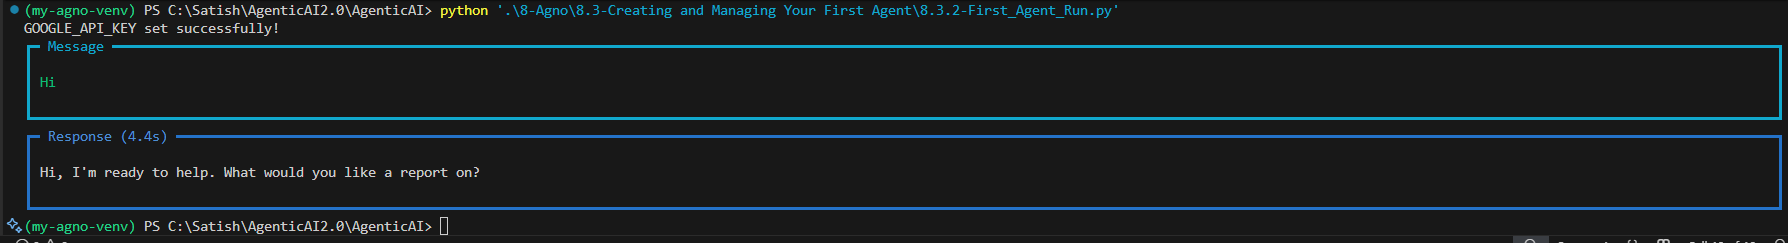

---

```Python
import os
from dotenv import load_dotenv

load_dotenv()

# Set your API key (replace YOUR_API_KEY with your actual key)
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")

# Verify it’s set
print("GOOGLE_API_KEY set successfully!")

from agno.agent import Agent
from agno.models.google import Gemini
from agno.tools.hackernews import HackerNewsTools

agent = Agent(
    model=Gemini(id="gemini-2.0-flash"),
    tools=[HackerNewsTools()],
    instructions="Write a report on the topic. Output only the report.",
    markdown=True,
)

agent.print_response(input="Trending startups and products and stories from hackernews")
```

### `Output`
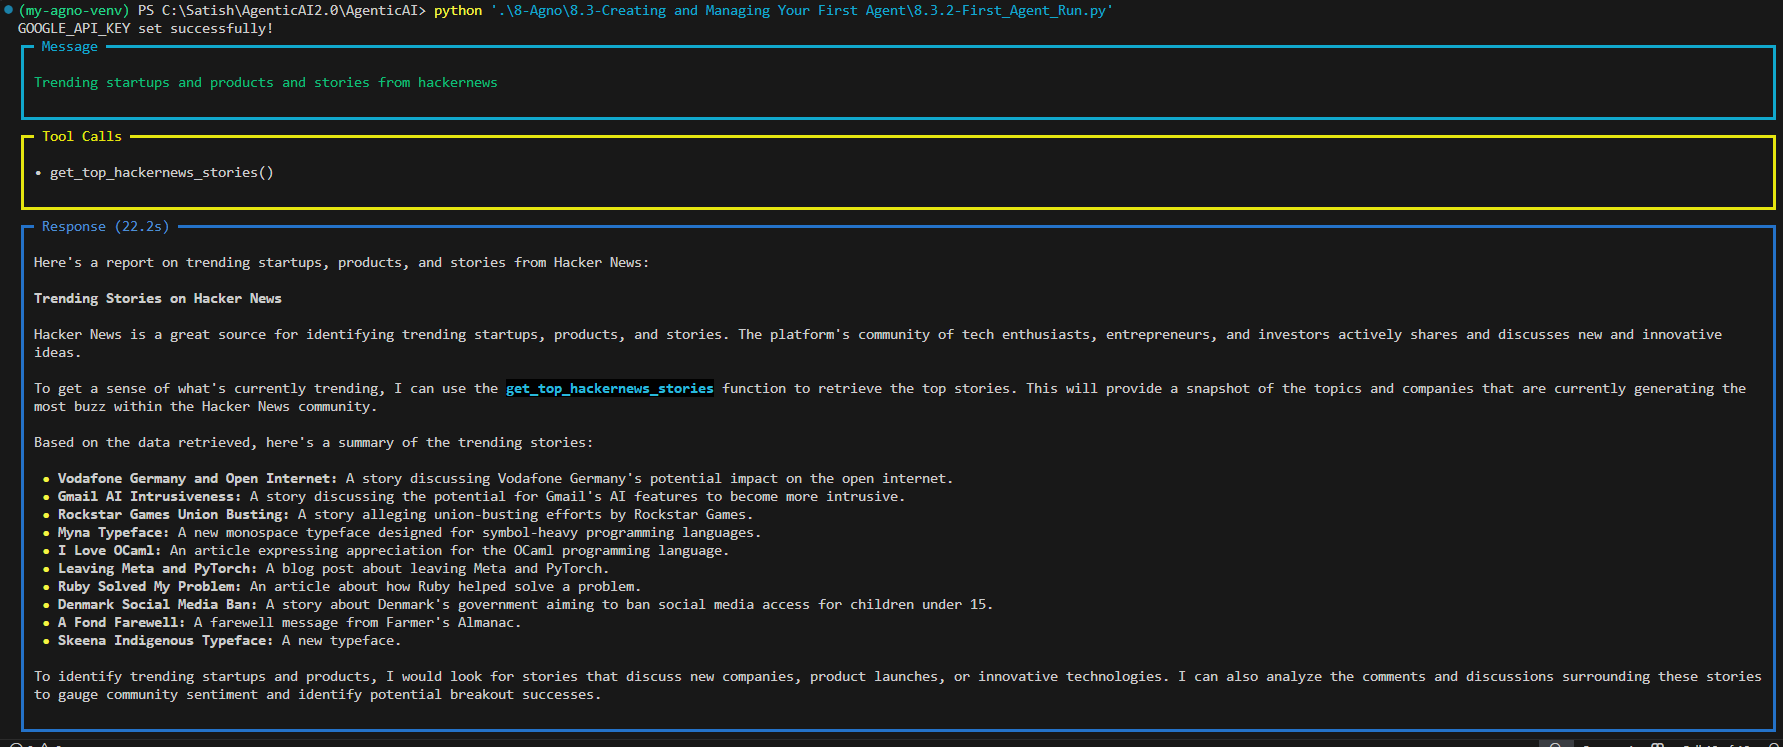 <br><br>
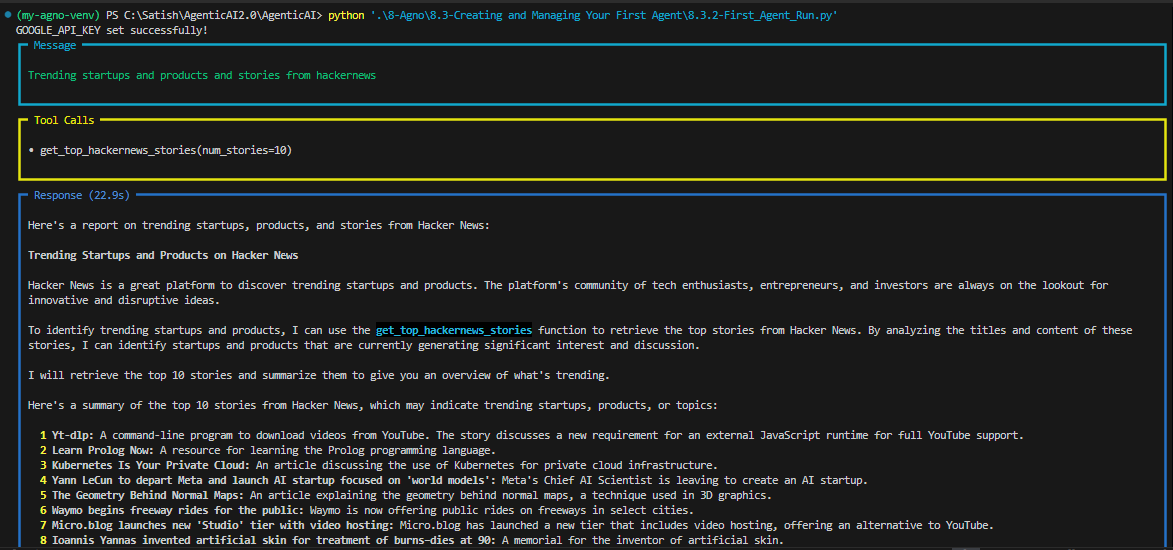 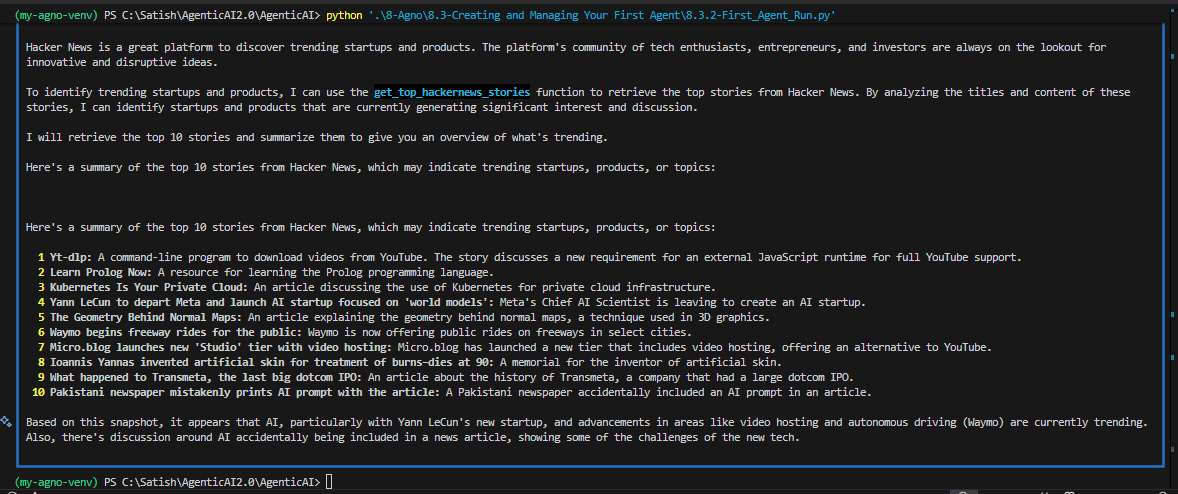
---